In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from typing import Tuple, List
from torch.distributions import Categorical
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:

class CartPoleEnvironment:
    def __init__(self) -> None:
        self.env = gym.make("CartPole-v1")
        self.state_dim: int = self.env.observation_space.shape[0]
        self.action_dim: int = self.env.action_space.n

    def reset(self,render: bool) -> torch.Tensor:
        if(render):
            self.env = gym.make("CartPole-v1", render_mode="human")
        else:
            self.env = gym.make("CartPole-v1")
        state = self.env.reset()
        return self._get_state_tensor(state[0])

    def _get_state_tensor(self, state) -> torch.Tensor:
        return torch.tensor(state, dtype=torch.float32)

    def step(self, action: int) -> Tuple[torch.Tensor, float, bool]:
        next_state, reward, done, _, _ = self.env.step(action)
        return self._get_state_tensor(next_state), reward, done

    def get_action_space_size(self) -> int:
        return self.action_dim

    def get_state_dimension(self) -> int:
        return self.state_dim

    def render(self) -> None:
        self.env.render()

    def close(self) -> None:
        self.env.close()

In [3]:
# Define the Policy Network (Actor)
class PolicyNetwork(nn.Module):
    """ MLP Actor network for PPO """
    def __init__(self, n_observations: int, n_actions: int):
        super(PolicyNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    def forward(self, x: torch.Tensor) -> Categorical:
        """
        Forward pass, returns a Categorical distribution.
        """
        if not isinstance(x, torch.Tensor):
             x = torch.tensor(x, dtype=torch.float32, device=device)
        elif x.dtype != torch.float32:
             x = x.to(dtype=torch.float32)
        if x.dim() == 1:
            x = x.unsqueeze(0)
            
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        action_logits = self.layer3(x)
        return Categorical(logits=action_logits)

# Define the Value Network (Critic)
class ValueNetwork(nn.Module):
    """ MLP Critic network for PPO """
    def __init__(self, n_observations: int):
        super(ValueNetwork, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass, returns the estimated state value.
        """
        if not isinstance(x, torch.Tensor):
             x = torch.tensor(x, dtype=torch.float32, device=device)
        elif x.dtype != torch.float32:
             x = x.to(dtype=torch.float32)
        if x.dim() == 1:
            x = x.unsqueeze(0)
            
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        state_value = self.layer3(x)
        return state_value

In [4]:
# Define the compute_gae function
def compute_gae(rewards: torch.Tensor, 
               values: torch.Tensor, 
               next_values: torch.Tensor, 
               dones: torch.Tensor, 
               gamma: float, 
               lambda_gae: float, 
               standardize: bool,
               epsilon_std: float) -> torch.Tensor:
    """
    Computes Generalized Advantage Estimation (GAE).
    """
    advantages = torch.zeros_like(rewards)
    last_advantage = 0.0

    for t in reversed(range(len(rewards))):
        mask = 1.0 - dones[t]
        delta = rewards[t] + gamma * next_values[t] * mask - values[t]
        advantages[t] = delta + gamma * lambda_gae * last_advantage * mask
        last_advantage = advantages[t]

    if standardize:
        mean_adv = torch.mean(advantages)
        std_adv = torch.std(advantages) + epsilon_std
        advantages = (advantages - mean_adv) / std_adv
        
    return advantages


In [5]:
# Modified update_ppo function
def update_ppo_with_kl(actor: PolicyNetwork,
                       critic: ValueNetwork,
                       actor_ref: PolicyNetwork, # Add reference actor
                       actor_optimizer: optim.Optimizer,
                       critic_optimizer: optim.Optimizer,
                       states: torch.Tensor,
                       actions: torch.Tensor,
                       log_probs_old: torch.Tensor,
                       advantages: torch.Tensor,
                       returns_to_go: torch.Tensor,
                       ppo_epochs: int,
                       ppo_clip_epsilon: float,
                       ppo_kl_beta: float,      # Add KL beta coefficient
                       value_loss_coeff: float,
                       entropy_coeff: float) -> Tuple[float, float, float, float]: # Return avg policy obj, value loss, KL div, entropy
    """
    Performs the PPO update for multiple epochs over the collected batch,
    INCLUDING a KL divergence penalty term in the actor loss.

    Parameters:
    - actor, critic: The networks being trained.
    - actor_ref: The frozen reference policy network for KL calculation.
    - actor_optimizer, critic_optimizer: The optimizers.
    - states, actions, log_probs_old, advantages, returns_to_go: Batch data tensors.
    - ppo_epochs (int): Number of optimization epochs.
    - ppo_clip_epsilon (float): Clipping parameter epsilon.
    - ppo_kl_beta (float): Coefficient for the KL divergence penalty.
    - value_loss_coeff (float): Coefficient for the value loss.
    - entropy_coeff (float): Coefficient for the entropy bonus.

    Returns:
    - Tuple[float, float, float, float]: Average policy objective (clipped surrogate),
                                         average value loss, average KL divergence,
                                         and average entropy over the epochs.
    """
    total_policy_objective = 0.0
    total_value_loss = 0.0
    total_entropy = 0.0
    total_kl_div = 0.0

    # Detach advantages and old log probs - they are treated as constants during the update
    advantages = advantages.detach()
    log_probs_old = log_probs_old.detach()
    returns_to_go = returns_to_go.detach()

    # Ensure reference actor is in eval mode and doesn't track gradients
    actor_ref.eval()

    for _ in range(ppo_epochs):
        # --- Actor (Policy) Update ---
        # Evaluate current policy
        policy_dist = actor(states)
        log_probs_new = policy_dist.log_prob(actions)
        entropy = policy_dist.entropy().mean() # Entropy for exploration bonus

        # Calculate ratio r_t(theta)
        ratio = torch.exp(log_probs_new - log_probs_old)

        # Calculate surrogate objectives
        surr1 = ratio * advantages
        surr2 = torch.clamp(ratio, 1.0 - ppo_clip_epsilon, 1.0 + ppo_clip_epsilon) * advantages

        # Clipped Surrogate Objective part
        clipped_surrogate_objective = torch.min(surr1, surr2).mean()

        # --- Calculate KL Divergence Penalty ---
        kl_div_estimate_mean = 0.0
        with torch.no_grad(): # No gradients for reference policy
             policy_dist_ref = actor_ref(states)
             log_probs_ref = policy_dist_ref.log_prob(actions)

        # Calculate KL divergence using the unbiased estimator: exp(log P_ref - log P) - (log P_ref - log P) - 1
        log_ratio_ref_curr = log_probs_ref - log_probs_new.detach() # Use detached log_probs_new for KL calc
        kl_div_estimate = torch.exp(log_ratio_ref_curr) - log_ratio_ref_curr - 1
        kl_div_estimate_mean = torch.relu(kl_div_estimate.mean()) # Ensure non-negative

        # --- Combine Actor Loss Terms ---
        # Loss = -ClippedSurrogate + KL_Penalty - EntropyBonus
        policy_loss = -clipped_surrogate_objective + ppo_kl_beta * kl_div_estimate_mean - entropy_coeff * entropy

        # Optimize the actor
        actor_optimizer.zero_grad()
        policy_loss.backward()
        actor_optimizer.step()

        # --- Critic (Value) Update ---
        # Predict values - ensure critic input is correctly handled
        values_pred = critic(states).squeeze() # Squeeze potential extra dimension

        # Value loss (MSE)
        value_loss = F.mse_loss(values_pred, returns_to_go)

        # Optimize the critic
        critic_optimizer.zero_grad()
        # Scale value loss before backward pass
        (value_loss_coeff * value_loss).backward()
        critic_optimizer.step()

        # Accumulate metrics for logging
        total_policy_objective += clipped_surrogate_objective.item() # Log positive objective
        total_value_loss += value_loss.item()
        total_entropy += entropy.item()
        total_kl_div += kl_div_estimate_mean.item()

    # Calculate average metrics over the epochs
    avg_policy_objective = total_policy_objective / ppo_epochs
    avg_value_loss = total_value_loss / ppo_epochs
    avg_entropy = total_entropy / ppo_epochs
    avg_kl_div = total_kl_div / ppo_epochs

    return avg_policy_objective, avg_value_loss, avg_kl_div, avg_entropy

In [6]:
# Set up device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [7]:
# Hyperparameters for PPO on Custom Grid World
GAMMA_PPO = 0.994             # Discount factor
GAE_LAMBDA_PPO = 0.994        # GAE lambda parameter
PPO_KL_BETA = 0.01           # KL penalty factor
ACTOR_LR = 3e-4              # Learning rate for the actor
CRITIC_LR_PPO = 1e-3         # Learning rate for the critic
PPO_EPOCHS = 10              # Number of optimization epochs per iteration
PPO_CLIP_EPSILON = 0.2       # PPO clipping epsilon
VALUE_LOSS_COEFF = 0.5       # Coefficient for value loss
ENTROPY_COEFF = 0.01         # Coefficient for entropy bonus
STANDARDIZE_ADV_PPO = True   # Whether to standardize advantages
NUM_ITERATIONS_PPO = 150     # Number of PPO iterations (policy updates)
GROUP_SIZE = 16                # Number of rollouts (episodes) per group (G)
MAX_STEPS_PER_EPISODE_PPO = 500 # Max steps per episode
EPSILON_STD = 1e-8             # Small value to prevent division by zero
INTERV_PRINT = 10              # Print losses every INTERV_PRINT steps
INTERV_RENDER = -1             # Render environment every INTERV_RENDER steps, if INTERV_RENDER = -1, it doesn't render

In [8]:
# Re-instantiate the environment
env_ppo: CartPoleEnvironment = CartPoleEnvironment()
n_actions_ppo: int = env_ppo.get_action_space_size()
n_observations_ppo: int = env_ppo.get_state_dimension()

# Initialize Actor and Critic
actor_ppo: PolicyNetwork = PolicyNetwork(n_observations_ppo, n_actions_ppo).to(device)
critic_ppo: ValueNetwork = ValueNetwork(n_observations_ppo).to(device)

# Initialize Optimizers
actor_optimizer_ppo: optim.Adam = optim.Adam(actor_ppo.parameters(), lr=ACTOR_LR)
critic_optimizer_ppo: optim.Adam = optim.Adam(critic_ppo.parameters(), lr=CRITIC_LR_PPO)

# Lists for plotting
ppo_iteration_rewards = []
ppo_iteration_avg_ep_lens = []
ppo_iteration_policy_losses = []
ppo_iteration_value_losses = []
ppo_iteration_entropies = []
ppo_iteration_kl_divs = []

print("Starting PPO Training")

# --- PPO Training Loop ---
for iteration in range(NUM_ITERATIONS_PPO):
    # --- 1. Collect Trajectories (Rollout Phase) --- 
    # Store data in lists temporarily
    batch_states_list = []
    batch_actions_list = []
    batch_log_probs_old_list = []
    batch_rewards_list = []
    batch_values_list = []
    batch_dones_list = []
    
    episode_rewards_in_iter = []
    episode_lengths_in_iter = []

    for rollout_idx in range(GROUP_SIZE):
        if INTERV_RENDER != -1:
            if rollout_idx==0 and iteration%INTERV_RENDER==0:
                state = env_ppo.reset(render=True)
            else:
                state = env_ppo.reset(render=False)
        else:
            state = env_ppo.reset(render=False)
        episode_reward = 0.0
        episode_steps = 0
        done = False
        
        for t in range(MAX_STEPS_PER_EPISODE_PPO):
            
            # Sample action and get value estimate
            with torch.no_grad():
                policy_dist = actor_ppo(state)
                value = critic_ppo(state).squeeze()
                
                action_tensor = policy_dist.sample()
                action = action_tensor.item()
                log_prob = policy_dist.log_prob(action_tensor)
            
            # Interact with environment
            next_state, reward, done = env_ppo.step(action)
            
            # Store data
            batch_states_list.append(state)
            batch_actions_list.append(action)
            batch_log_probs_old_list.append(log_prob)
            batch_values_list.append(value)
            batch_rewards_list.append(reward)
            batch_dones_list.append(float(done))
            
            state = next_state
            episode_reward += reward
            episode_steps += 1
            
            if done or t==MAX_STEPS_PER_EPISODE_PPO-1:
                episode_rewards_in_iter.append(episode_reward)
                episode_lengths_in_iter.append(episode_steps)
                break
    
    # --- End Rollout --- 

    # Calculate next_values for GAE
    # For non-terminal states, next_value is the value of the next state
    # For terminal states, next_value is 0
    next_values = []
    with torch.no_grad():
        for i in range(len(batch_states_list)):
            if batch_dones_list[i] > 0.5:  # If done
                next_values.append(torch.tensor(0.0))
            elif i == len(batch_states_list) - 1:  # Last state in batch
                next_state = env_ppo.step(batch_actions_list[i])[0]  # Get next state
                next_values.append(critic_ppo(next_state).squeeze())
            else:  # Not done, use value of next state in batch
                next_values.append(batch_values_list[i+1])

    # Convert lists to tensors
    states_tensor = torch.stack(batch_states_list).to(device)
    actions_tensor = torch.tensor(batch_actions_list, dtype=torch.long, device=device)
    log_probs_old_tensor = torch.stack(batch_log_probs_old_list).squeeze().to(device)
    rewards_tensor = torch.tensor(batch_rewards_list, dtype=torch.float32, device=device)
    values_tensor = torch.stack(batch_values_list).to(device)
    next_values_tensor = torch.stack(next_values).to(device)
    dones_tensor = torch.tensor(batch_dones_list, dtype=torch.float32, device=device)

    # --- 2. Estimate Advantages & Returns-to-go --- 
    advantages_tensor = compute_gae(
        rewards_tensor, values_tensor, next_values_tensor, dones_tensor, 
        GAMMA_PPO, GAE_LAMBDA_PPO, standardize=STANDARDIZE_ADV_PPO,epsilon_std=EPSILON_STD
    )
    returns_to_go_tensor = advantages_tensor + values_tensor

    # --- Create Reference Actor (Snapshot before update) ---
    actor_ref = PolicyNetwork(n_observations_ppo, n_actions_ppo).to(device)
    actor_ref.load_state_dict(actor_ppo.state_dict())
    actor_ref.eval()
    
    # --- 3. Perform PPO Update --- 
    avg_policy_loss, avg_value_loss, avg_kl, avg_entropy = update_ppo_with_kl(
        actor=actor_ppo,
        critic=critic_ppo,
        actor_ref=actor_ref,             # <<< Pass reference actor
        actor_optimizer=actor_optimizer_ppo,
        critic_optimizer=critic_optimizer_ppo,
        states=states_tensor,
        actions=actions_tensor,
        log_probs_old=log_probs_old_tensor.squeeze(), # Squeeze log probs
        advantages=advantages_tensor,
        returns_to_go=returns_to_go_tensor,
        ppo_epochs=PPO_EPOCHS,
        ppo_clip_epsilon=PPO_CLIP_EPSILON,
        ppo_kl_beta=PPO_KL_BETA,         # <<< Pass KL beta
        value_loss_coeff=VALUE_LOSS_COEFF,
        entropy_coeff=ENTROPY_COEFF
    )


    # --- Logging --- 
    avg_reward_iter = np.mean(episode_rewards_in_iter) if episode_rewards_in_iter else np.nan
    avg_len_iter = np.mean(episode_lengths_in_iter) if episode_lengths_in_iter else np.nan

    ppo_iteration_rewards.append(avg_reward_iter)
    ppo_iteration_avg_ep_lens.append(avg_len_iter)
    ppo_iteration_policy_losses.append(avg_policy_loss)
    ppo_iteration_value_losses.append(avg_value_loss)
    ppo_iteration_entropies.append(avg_entropy)
    ppo_iteration_kl_divs.append(avg_kl)

    if (iteration + 1) % INTERV_PRINT == 0:
        print(f"Iter {iteration+1}/{NUM_ITERATIONS_PPO} | Avg Reward: {avg_reward_iter:.2f} | Avg Len: {avg_len_iter:.1f} | P_Loss: {avg_policy_loss:.4f} | V_Loss: {avg_value_loss:.4f} | Entropy: {avg_entropy:.4f}")

env_ppo.close()
print("\nPPO Training Loop Finished (CartPole).")

Starting PPO Training
Iter 10/150 | Avg Reward: 68.56 | Avg Len: 68.6 | P_Loss: 0.0054 | V_Loss: 0.7434 | Entropy: 0.6171
Iter 20/150 | Avg Reward: 215.81 | Avg Len: 215.8 | P_Loss: 0.0008 | V_Loss: 0.7781 | Entropy: 0.5742
Iter 30/150 | Avg Reward: 392.75 | Avg Len: 392.8 | P_Loss: 0.0022 | V_Loss: 0.8811 | Entropy: 0.5386
Iter 40/150 | Avg Reward: 390.62 | Avg Len: 390.6 | P_Loss: 0.0034 | V_Loss: 0.8782 | Entropy: 0.5285
Iter 50/150 | Avg Reward: 500.00 | Avg Len: 500.0 | P_Loss: -0.0001 | V_Loss: 0.9035 | Entropy: 0.5080
Iter 60/150 | Avg Reward: 500.00 | Avg Len: 500.0 | P_Loss: 0.0006 | V_Loss: 0.9931 | Entropy: 0.4995
Iter 70/150 | Avg Reward: 497.50 | Avg Len: 497.5 | P_Loss: 0.0004 | V_Loss: 1.0110 | Entropy: 0.4991
Iter 80/150 | Avg Reward: 500.00 | Avg Len: 500.0 | P_Loss: 0.0002 | V_Loss: 1.0036 | Entropy: 0.5113
Iter 90/150 | Avg Reward: 500.00 | Avg Len: 500.0 | P_Loss: 0.0009 | V_Loss: 0.9659 | Entropy: 0.5202
Iter 100/150 | Avg Reward: 494.31 | Avg Len: 494.3 | P_Loss: 

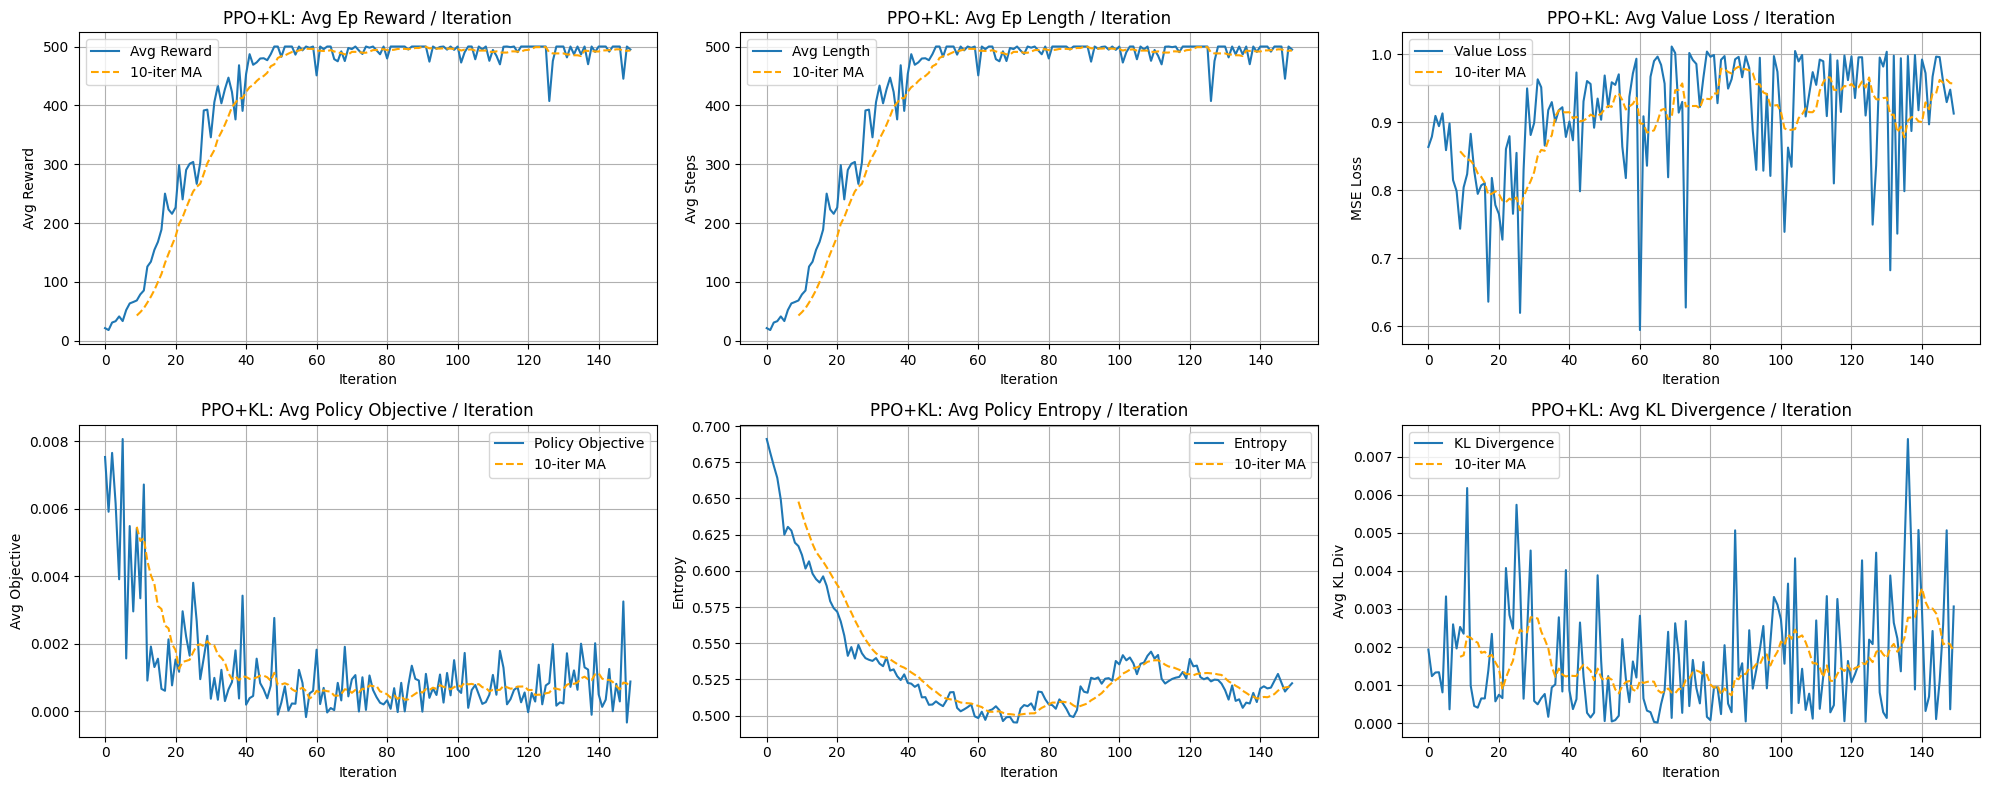

In [9]:

# Assume the following lists are populated from the PPO+KL training loop:
# ppo_iteration_rewards
# ppo_iteration_avg_ep_lens
# ppo_iteration_policy_losses  # Contains avg_policy_objective values
# ppo_iteration_value_losses
# ppo_iteration_entropies
# ppo_iteration_kl_divs

# --- Plotting results for PPO with KL Penalty ---
plt.figure(figsize=(20, 8)) # Adjusted figsize slightly for 2x3 grid

# --- 1. Average Rewards per Iteration ---
plt.subplot(2, 3, 1)
# Filter NaNs
valid_rewards_ppo = [r for r in ppo_iteration_rewards if r is not None and not np.isnan(r)]
valid_indices_rewards = [i for i, r in enumerate(ppo_iteration_rewards) if r is not None and not np.isnan(r)]
if valid_indices_rewards:
    plt.plot(valid_indices_rewards, valid_rewards_ppo, label='Avg Reward')
    # Add moving average
    if len(valid_rewards_ppo) >= 10:
        rewards_ma_ppo = np.convolve(valid_rewards_ppo, np.ones(10)/10, mode='valid')
        ma_indices_rewards = valid_indices_rewards[len(valid_rewards_ppo) - len(rewards_ma_ppo):]
        plt.plot(ma_indices_rewards, rewards_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
plt.title('PPO+KL: Avg Ep Reward / Iteration')
plt.xlabel('Iteration')
plt.ylabel('Avg Reward')
plt.grid(True)

# --- 2. Average Episode Length per Iteration ---
plt.subplot(2, 3, 2)
# Filter NaNs
valid_lens_ppo = [l for l in ppo_iteration_avg_ep_lens if l is not None and not np.isnan(l)]
valid_indices_lens = [i for i, l in enumerate(ppo_iteration_avg_ep_lens) if l is not None and not np.isnan(l)]
if valid_indices_lens:
    plt.plot(valid_indices_lens, valid_lens_ppo, label='Avg Length')
    # Add moving average
    if len(valid_lens_ppo) >= 10:
        lens_ma_ppo = np.convolve(valid_lens_ppo, np.ones(10)/10, mode='valid')
        ma_indices_lens = valid_indices_lens[len(valid_lens_ppo) - len(lens_ma_ppo):]
        plt.plot(ma_indices_lens, lens_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
plt.title('PPO+KL: Avg Ep Length / Iteration')
plt.xlabel('Iteration')
plt.ylabel('Avg Steps')
plt.grid(True)

# --- 3. Critic (Value) Loss per Iteration ---
plt.subplot(2, 3, 3)
# Filter NaNs
valid_vloss_ppo = [l for l in ppo_iteration_value_losses if l is not None and not np.isnan(l)]
valid_indices_vloss = [i for i, l in enumerate(ppo_iteration_value_losses) if l is not None and not np.isnan(l)]
if valid_indices_vloss:
    plt.plot(valid_indices_vloss, valid_vloss_ppo, label='Value Loss')
    # Add moving average
    if len(valid_vloss_ppo) >= 10:
        vloss_ma_ppo = np.convolve(valid_vloss_ppo, np.ones(10)/10, mode='valid')
        ma_indices_vloss = valid_indices_vloss[len(valid_vloss_ppo) - len(vloss_ma_ppo):]
        plt.plot(ma_indices_vloss, vloss_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
plt.title('PPO+KL: Avg Value Loss / Iteration')
plt.xlabel('Iteration')
plt.ylabel('MSE Loss')
plt.grid(True)

# --- 4. Actor Policy Objective per Iteration ---
plt.subplot(2, 3, 4)
# Filter NaNs - ppo_iteration_policy_losses should store the objective value directly
valid_pobj_ppo = [p for p in ppo_iteration_policy_losses if p is not None and not np.isnan(p)]
valid_indices_pobj = [i for i, p in enumerate(ppo_iteration_policy_losses) if p is not None and not np.isnan(p)]
if valid_indices_pobj:
    plt.plot(valid_indices_pobj, valid_pobj_ppo, label='Policy Objective')
    # Add moving average
    if len(valid_pobj_ppo) >= 10:
        pobj_ma_ppo = np.convolve(valid_pobj_ppo, np.ones(10)/10, mode='valid')
        ma_indices_pobj = valid_indices_pobj[len(valid_pobj_ppo) - len(pobj_ma_ppo):]
        plt.plot(ma_indices_pobj, pobj_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
# Changed title and Y-label to reflect objective directly
plt.title('PPO+KL: Avg Policy Objective / Iteration')
plt.xlabel('Iteration')
plt.ylabel('Avg Objective')
plt.grid(True)

# --- 5. Entropy per Iteration ---
plt.subplot(2, 3, 5)
# Filter NaNs
valid_ent_ppo = [e for e in ppo_iteration_entropies if e is not None and not np.isnan(e)]
valid_indices_ent = [i for i, e in enumerate(ppo_iteration_entropies) if e is not None and not np.isnan(e)]
if valid_indices_ent:
    plt.plot(valid_indices_ent, valid_ent_ppo, label='Entropy')
    # Add moving average
    if len(valid_ent_ppo) >= 10:
        entropy_ma_ppo = np.convolve(valid_ent_ppo, np.ones(10)/10, mode='valid')
        ma_indices_ent = valid_indices_ent[len(valid_ent_ppo) - len(entropy_ma_ppo):]
        plt.plot(ma_indices_ent, entropy_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
plt.title('PPO+KL: Avg Policy Entropy / Iteration')
plt.xlabel('Iteration')
plt.ylabel('Entropy')
plt.grid(True)

# --- 6. KL Divergence per Iteration --- <<< ADDED PLOT
plt.subplot(2, 3, 6)
# Filter NaNs
valid_kl_ppo = [k for k in ppo_iteration_kl_divs if k is not None and not np.isnan(k)]
valid_indices_kl = [i for i, k in enumerate(ppo_iteration_kl_divs) if k is not None and not np.isnan(k)]
if valid_indices_kl:
    plt.plot(valid_indices_kl, valid_kl_ppo, label='KL Divergence')
    # Add moving average
    if len(valid_kl_ppo) >= 10:
        kl_ma_ppo = np.convolve(valid_kl_ppo, np.ones(10)/10, mode='valid')
        ma_indices_kl = valid_indices_kl[len(valid_kl_ppo) - len(kl_ma_ppo):]
        plt.plot(ma_indices_kl, kl_ma_ppo, label='10-iter MA', color='orange', linestyle='--')
    plt.legend()
plt.title('PPO+KL: Avg KL Divergence / Iteration')
plt.xlabel('Iteration')
plt.ylabel('Avg KL Div')
plt.grid(True)

plt.tight_layout() # Adjust layout
plt.show()